# Risk Analysis and Measurement Python Project

## Project Overview: Risk Analysis Toolkit

We'll create a Python script that:


*   Classifies different types of risks
*   Implements basic risk measurement techniques (VaR, Expected Shortfall)


*   Visualizes risk distributions
*   Provides examples of risk scenarios

In [9]:
# Import necessary libraries
import numpy as np  # For numerical operations
import matplotlib.pyplot as plt  # For plotting graphs
from scipy.stats import norm, t  # For normal and t-distributions

# ===========================================
# PART 1: RISK CLASSIFICATION
# ===========================================
# Here we categorize risks (like Market Risk, Credit Risk, etc.)

def classify_risk(risk_name):

    # Mapping of risk categories
    risk_categories = {
        "Market Risk": ["Equity risk", "Interest rate risk", "Commodity risk"],
        "Credit Risk": ["Late Payment", "Customer default"],
        "Operational Risk": ["Human error", "System failure"],
        "Other Risk": []
    }

  # Check which category eah risk belongs to
    for category, risks in risk_categories.items():
      if risk_name in risks:
       return category

  # When it is not found, return "Other Risk"
    return "Other Risk"



In [10]:

# ===========================================
# PART 2: RISK MEASUREMENT (VaR & Expected Shortfall)
# ===========================================

def calculate_var(data, confidence_level=0.95):
    """
    Calculates Value at Risk (VaR) - the worst loss expected at a given confidence level.

    Parameters:
    - data (list or numpy array): Historical losses or returns
    - confidence_level (float, 0 to 1): Probability level (e.g., 0.95 for 95%)

    Returns:
    - float: VaR value
    """

    # Sort the data to find the worst losses
    sorted_losses = np.sort(data)

    # Find the index corresponding to the confidence level
    var_index = int(confidence_level * len(sorted_losses))

    # VaR is the loss at this index
    var = sorted_losses[var_index]

    return var

def calculate_es(data, confidence_level=0.95):
    """
    Calculates Expected Shortfall (ES) - the average loss beyond VaR.

    Parameters:
    - data (list or numpy array): Historical losses or returns
    - confidence_level (float, 0 to 1): Probability level (e.g., 0.95 for 95%)

    Returns:
    - float: Expected Shortfall value
    """

    # First, calculate VaR
    var = calculate_var(data, confidence_level)

    # Find all losses worse than VaR
    losses_beyond_var = [loss for loss in data if loss >= var]

    # ES is the average of these losses
    es = np.mean(losses_beyond_var)

    return es

=== Risk Classification Example ===
'Interest rate risk' is classified as: Market Risk
'Human error' is classified as: Operational Risk
'Unknown risk' is classified as: Other Risk

=== Risk Measurement Example ===
95% VaR: 1.6871416350725648
95% Expected Shortfall: 2.099530083430724


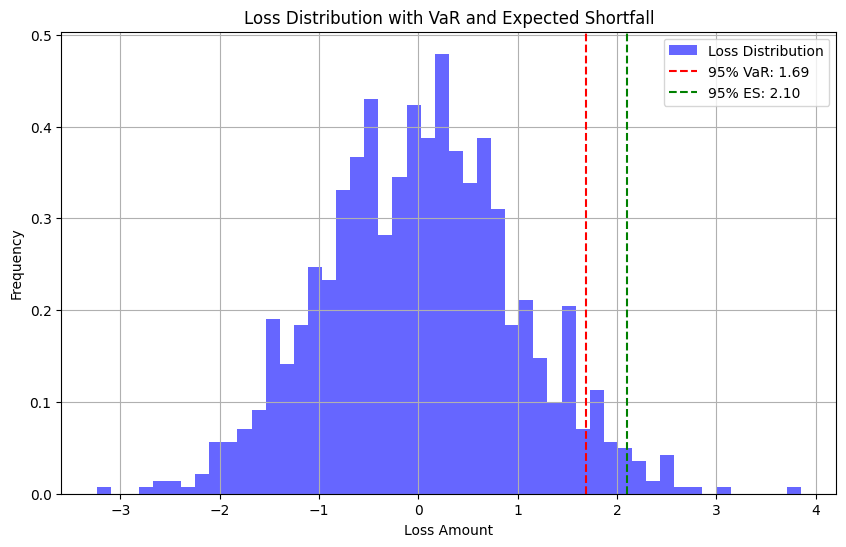

In [11]:

# ===========================================
# PART 3: VISUALIZING RISK
# ===========================================
# This part plots the loss distribution with VaR and ES.

def plot_risk(losses):
    """
    Plots the loss distribution and marks VaR and Expected Shortfall.

    Parameters:
    - losses (list or numpy array): Simulated loss data
    """

    plt.figure(figsize=(10, 6))

    # Plot histogram of losses
    plt.hist(losses, bins=50, density=True, alpha=0.6, color="blue", label="Loss Distribution")

    # Calculate VaR and ES
    var = calculate_var(losses)
    es = calculate_es(losses)

    # Mark VaR and ES on the plot
    plt.axvline(var, color="red", linestyle="--", label=f"95% VaR: {var:.2f}")
    plt.axvline(es, color="green", linestyle="--", label=f"95% ES: {es:.2f}")

    plt.title("Loss Distribution with VaR and Expected Shortfall")
    plt.xlabel("Loss Amount")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True)
    plt.show()

# ===========================================
# PART 4: RUNNING THE ANALYSIS
# ===========================================
# This part demonstrates the functions with examples.

def main():
    """
    Main function to run the risk analysis.
    """

    print("=== Risk Classification Example ===")
    print("'Interest rate risk' is classified as:", classify_risk("Interest rate risk"))
    print("'Human error' is classified as:", classify_risk("Human error"))
    print("'Unknown risk' is classified as:", classify_risk("Unknown risk"))

    print("\n=== Risk Measurement Example ===")

    # Simulate some loss data (normally distributed)
    np.random.seed(42)  # For reproducibility
    losses = np.random.normal(loc=0, scale=1, size=1000)  # 1000 random losses

    print("95% VaR:", calculate_var(losses))
    print("95% Expected Shortfall:", calculate_es(losses))

    # Plot the results
    plot_risk(losses)

# Run the program
if __name__ == "__main__":
      main()

